In [1]:
import pandas as pd
dataset = pd.read_csv("Social_Network_Ads.csv")

In [2]:
dataset.head(2)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0


In [3]:
dataset = dataset.drop(columns=(['User ID']))

In [4]:
dataset.head(2)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0


In [5]:
dataset = pd.get_dummies(dataset, dtype=int, drop_first=True)

In [6]:
dataset.head(2)

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1


In [7]:
dataset.columns

Index(['Age', 'EstimatedSalary', 'Purchased', 'Gender_Male'], dtype='object')

In [9]:
independent=dataset[['Age', 'EstimatedSalary','Gender_Male']]
dependent=dataset[['Purchased']]

In [10]:
dependent.value_counts()

Purchased
0            257
1            143
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(independent, dependent, test_size=1/3, random_state=0)

In [12]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [13]:
X_train=sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
from sklearn.model_selection import GridSearchCV

In [16]:
param_grid = {'criterion':['gini', 'entropy'],
              'max_features':['sqrt', 'auto','log2'], 
              'n_estimators':[10,100]}

In [17]:
grid = GridSearchCV(RandomForestClassifier(), param_grid, refit=True, verbose=3, n_jobs=-1, scoring='f1_weighted')

In [18]:
import warnings
warnings.filterwarnings('ignore')

In [19]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', 'auto', ...], 'n_estimators': [10, 100]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [20]:
re=grid.cv_results_

In [21]:
grid_pred = grid.predict(X_test)

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

In [23]:
cm=confusion_matrix(y_test, grid_pred)
print(cm)

[[78  7]
 [ 4 45]]


In [24]:
clf=classification_report(y_test,grid_pred)
print(clf)

              precision    recall  f1-score   support

           0       0.95      0.92      0.93        85
           1       0.87      0.92      0.89        49

    accuracy                           0.92       134
   macro avg       0.91      0.92      0.91       134
weighted avg       0.92      0.92      0.92       134



In [25]:
print("The best grid parameter is {}".format(grid.best_params_))

The best grid parameter is {'criterion': 'entropy', 'max_features': 'sqrt', 'n_estimators': 100}


In [26]:
from sklearn.metrics import f1_score
f1_macro = f1_score(y_test,grid_pred,average='weighted')
print("The F1 value for the best grid parameter is {}".format(grid.best_params_), f1_macro)

The F1 value for the best grid parameter is {'criterion': 'entropy', 'max_features': 'sqrt', 'n_estimators': 100} 0.9183922682195829


In [27]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, grid.predict_proba(X_test)[:,1])

0.9650660264105642

In [28]:
import matplotlib.pyplot as plt
from sklearn import metrics

In [29]:
y_pred_proba= grid.predict_proba(X_test)[:,1]

In [30]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)

In [31]:
roc_auc = metrics.roc_auc_score(y_test, y_pred_proba)

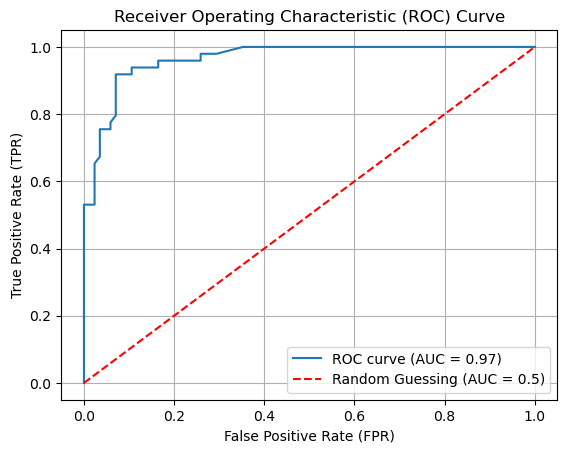

In [32]:
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guessing (AUC = 0.5)') # Diagonal baseline
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [33]:
table = pd.DataFrame.from_dict(re)

In [34]:
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.069184,0.005665,0.032511,0.003380,gini,sqrt,10,"{'criterion': 'gini', 'max_features': 'sqrt', ...",0.804764,0.888107,0.851527,0.943699,0.961755,0.889970,0.057933,5
1,0.543163,0.005540,0.052531,0.003717,gini,sqrt,100,"{'criterion': 'gini', 'max_features': 'sqrt', ...",0.847141,0.888107,0.851527,0.925272,0.943699,0.891149,0.038579,4
2,0.003451,0.000375,0.000000,0.000000,gini,auto,10,"{'criterion': 'gini', 'max_features': 'auto', ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
3,0.003422,0.001236,0.000000,0.000000,gini,auto,100,"{'criterion': 'gini', 'max_features': 'auto', ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
4,0.056339,0.005896,0.025706,0.001776,gini,log2,10,"{'criterion': 'gini', 'max_features': 'log2', ...",0.847141,0.831253,0.851527,0.925272,0.962264,0.883491,0.051035,6
5,0.564729,0.004877,0.047265,0.004221,gini,log2,100,"{'criterion': 'gini', 'max_features': 'log2', ...",0.867478,0.888107,0.851527,0.925272,0.943699,0.895217,0.034591,2
6,0.064002,0.002545,0.030724,0.003496,entropy,sqrt,10,"{'criterion': 'entropy', 'max_features': 'sqrt...",0.782557,0.808392,0.851527,0.906166,0.942166,0.858162,0.059327,8
7,0.511584,0.010470,0.043244,0.003494,entropy,sqrt,100,"{'criterion': 'entropy', 'max_features': 'sqrt...",0.867478,0.907177,0.851527,0.944161,0.962264,0.906522,0.042598,1
8,0.004913,0.000755,0.000000,0.000000,entropy,auto,10,"{'criterion': 'entropy', 'max_features': 'auto...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
9,0.002466,0.001325,0.000000,0.000000,entropy,auto,100,"{'criterion': 'entropy', 'max_features': 'auto...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
